10. I denna uppgift ska vi använda MNIST-datan som vi arbetat med tidigare. Detta för att ha ett bekant dataset att arbeta med och experimentera med ANN-modeller. 
a) Träna en ANN-modell på MNIST-datan. Vad får du för resultat? 

b) Prova justera hyperparametrarna med *KerasTuner*. Notera, du har som vanligt dokumentationen till din hjälp. Får du bättre resultat? 

In [2]:
#Imports
%pip install tensorflow keras-tuner
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype('float32') / 255.0  #normalisera till [0, 1]
X_test = X_test.astype('float32') / 255.0  #normalisera till [0, 1]

print(f"Träningsdata form: {X_train.shape}")
print(f"Testdata form: {X_test.shape}")

  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.0.1-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached grpcio-1.76.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached ten


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Träningsdata form: (60000, 28, 28)
Testdata form: (10000, 28, 28)


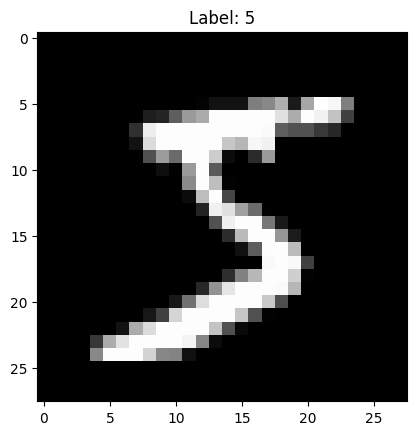

In [3]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:


model_a = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),  #784 pixlar
    layers.Dense(128, activation='relu'),  # hidden layer med 128 noder, relu för att hantera icke-linearitet som tillexemepl en loop på en 8
    layers.Dropout(0.2),    # stänger av 20% av noderna under träning för att undvika överanpassning              
    layers.Dense(10, activation='softmax')  # output layer med 10 noder för 10 klasser (0-9), softmax för sannolikhetsfördelning
])


model_a.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # klassificeringsproblem med heltalslabels och för att straffa modellen när den gissar fel med högt självförtroende
              metrics=['accuracy'])


print("Startar träning")
history = model_a.fit(X_train, y_train, epochs=5, validation_split=0.2)


test_loss, test_acc = model_a.evaluate(X_test, y_test)
print(f"\nResultat uppgift a - Test accuracy: {test_acc:.4f}")

Startar träning
Epoch 1/5


e:\AI kod\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9054 - loss: 0.3244 - val_accuracy: 0.9523 - val_loss: 0.1642
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9530 - loss: 0.1609 - val_accuracy: 0.9605 - val_loss: 0.1263
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9632 - loss: 0.1206 - val_accuracy: 0.9696 - val_loss: 0.1020
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9709 - loss: 0.0967 - val_accuracy: 0.9715 - val_loss: 0.0995
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9745 - loss: 0.0821 - val_accuracy: 0.9738 - val_loss: 0.0898
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 0.9760 - loss: 0.0786

Resultat uppgift a - Test accuracy: 0.9760


In [4]:

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))
    
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32) # här säger vi att du ska välja ett heltal mellan 32 och 512 med steg om 32
    model.add(layers.Dense(units=hp_units, activation='relu')) #stoppar in det valda antalet noder här
    
    model.add(layers.Dense(10, activation='softmax'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4]) #här väljer vi mellan tre olika inlärningshastigheter 
    #1e-2(snabbilärning, 0.01), 1e-3(standard, 0.001) och 1e-4(långsam/finlir, 0.0001)

    # Vi använder de valde värdet i optimeraren
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    # skickar tillbaka den färdiga men ontränade modellen till tunern
    return model

In [5]:
# Tuning

tuner = kt.Hyperband(build_model, # hyperband för att leta efter den bästa modellen snabbt
                     objective='val_accuracy', 
                     max_epochs=10, #maximalt 10 epoker per modell
                     factor=3, #behåller 1/3 av modellerna och kastar resterande
                     directory='my_dir',
                     project_name='KT_mnist')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

print("Startar sökning efter hyperparametrar")
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])

# Hämta de bästa hyperparametrarna
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Sökningen är klar. 
Optimalt antal neuroner: {best_hps.get('units')}
Optimal learning rate: {best_hps.get('learning_rate')}
""")

Trial 30 Complete [00h 00m 23s]
val_accuracy: 0.9783333539962769

Best val_accuracy So Far: 0.9793333411216736
Total elapsed time: 00h 04m 35s

Sökningen är klar. 
Optimalt antal neuroner: 288
Optimal learning rate: 0.001



In [6]:
# Träna den bästa modellen (Uppgift b resultat)

# Bygg modellen med de bästa värdena
model_b = tuner.hypermodel.build(best_hps)

# Träna den
history_b = model_b.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Utvärdera
test_loss_b, test_acc_b = model_b.evaluate(X_test, y_test)
print(f"\nResultat uppgift b (Optimerad) - Test accuracy: {test_acc_b:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9289 - loss: 0.2450 - val_accuracy: 0.9629 - val_loss: 0.1288
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9698 - loss: 0.1001 - val_accuracy: 0.9730 - val_loss: 0.0959
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9804 - loss: 0.0648 - val_accuracy: 0.9719 - val_loss: 0.0965
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9867 - loss: 0.0450 - val_accuracy: 0.9735 - val_loss: 0.0898
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9894 - loss: 0.0339 - val_accuracy: 0.9754 - val_loss: 0.0839
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.9759 - val_loss: 0.0850
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9943 - loss: 0.0179 - val_accuracy: 0.9770 - val_loss: 0.0910
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9947 - loss: 0.0164 - 